In [2]:
import numpy as np
import cv2
import os

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_params = cv2.aruco.DetectorParameters()
aruco_params.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX
aruco_params.cornerRefinementWinSize = 10
aruco_params.cornerRefinementMaxIterations = 60
aruco_params.cornerRefinementMinAccuracy = 0.001

detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

tag_size = 0.06 # in meters
obj_corners = {}
imgsize = None

for i in range(6):
    dx = (i % 2) * 0.09
    dy = (i // 2) * 0.07567
    obj_corners[i] = np.array([
        [dx, dy, 0.0],
        [dx + tag_size, dy, 0.0],
        [dx + tag_size, dy + tag_size, 0.0],
        [dx, dy + tag_size, 0.0]
    ], dtype=np.float32)



objectPoints, imagePoints = [], []

path = "calibration2"
filelists = os.listdir(path)

for i in range(len(filelists)):
    filename = f"{path}/{filelists[i]}"
    if not os.path.exists(filename):
        # print(f"file not found: {filename}")
        continue
    img = cv2.imread(filename)
    if imgsize is None:
        imgsize = (img.shape[1], img.shape[0])
        print(f"image size: {imgsize[0]} x {imgsize[1]}")
    # print(f"image size: {img.shape[1]} x {img.shape[0]}")
    corners, ids, rejected = detector.detectMarkers(img)
    if ids is None or len(ids) == 0:
        continue

    # cv2.aruco.drawDetectedMarkers(img, corners, ids)  # 画框 + ID，默认绿色

    # # 你可以选择显示，或保存到文件
    # # 显示（如果是在本地跑）：
    # # cv2.imshow("detected", img)
    # # cv2.waitKey(0)

    # # 保存到文件（比如到 output 文件夹）：
    # os.makedirs("viz_cal_detect", exist_ok=True)
    # out_name = os.path.join("viz_cal_detect", filelists[i])
    # cv2.imwrite(out_name, img)

    obj_pts_this = []
    img_pts_this = []
    # print(f"i = {i}")
    for j in range(len(ids)):
        id = ids[j][0]
        corner = corners[j][0]
        img_pts_this.append(corner.astype(np.float32))
        obj_pts_this.append(obj_corners[id])

    imagePoints.append(np.vstack(img_pts_this).astype(np.float32))
    objectPoints.append(np.vstack(obj_pts_this).astype(np.float32))

print(f"available pictures: {len(objectPoints)}")

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
    objectPoints = objectPoints,
    imagePoints = imagePoints,
    imageSize = imgsize,
    cameraMatrix = None,
    distCoeffs = None
)

print("ret:", ret)

image size: 4284 x 5712
available pictures: 32
ret: 1.8129826180764497


In [5]:
path = "toy2"
filelists = os.listdir(path)
print(filelists)

single_tag_size = 0.06
desired_id = 6

objp_single = np.array(
    [
        [0.0, 0.0, 0.0],
        [single_tag_size, 0.0, 0.0],
        [single_tag_size, single_tag_size, 0.0],
        [0.0, single_tag_size, 0.0]
    ], dtype=np.float32
)

pose_files = []
pnp_rvecs, pnp_tvecs = [], []
c2w_list = []

for i, fn in enumerate(filelists):
    img = cv2.imread(os.path.join(path, fn))
    if img is None:
        continue

    corners, ids, _ = detector.detectMarkers(img)
    if ids is None or len(ids) == 0:
        continue

    imgp = corners[0][0].astype(np.float32)
    ok, rvec, tvec = cv2.solvePnP(objp_single, imgp, mtx, dist)

    if not ok:
        print(f"PnP failed for image {fn}")
        continue

    pnp_rvecs.append(rvec)
    pnp_tvecs.append(tvec)
    pose_files.append(os.path.join(path, fn))

    R, _ = cv2.Rodrigues(rvec)
    t = tvec.reshape(3, 1)
    c2w_R = R.T
    c2w_t = -R.T @ t
    c2w = np.eye(4, dtype=np.float64)
    c2w[:3, :3] = c2w_R
    c2w[:3, 3] = c2w_t.flatten()
    c2w_list.append(c2w)

    print(f"Processed {i+1}/{len(filelists)}: {fn}")

np.savez(
    "toy2_camera_poses.npz",
    K = mtx,
    dist = dist,
    files=np.array(pose_files),
    rvecs=np.array(pnp_rvecs, dtype=object),
    tvecs=np.array(pnp_tvecs, dtype=object),
    c2w = np.array(c2w_list)
)

# print(pose_files)

['IMG_3168.JPG', 'IMG_3169.JPG', 'IMG_3170.JPG', 'IMG_3171.JPG', 'IMG_3172.JPG', 'IMG_3173.JPG', 'IMG_3174.JPG', 'IMG_3175.JPG', 'IMG_3176.JPG', 'IMG_3177.JPG', 'IMG_3178.JPG', 'IMG_3179.JPG', 'IMG_3180.JPG', 'IMG_3181.JPG', 'IMG_3182.JPG', 'IMG_3183.JPG', 'IMG_3184.JPG', 'IMG_3185.JPG', 'IMG_3186.JPG', 'IMG_3187.JPG', 'IMG_3188.JPG', 'IMG_3189.JPG', 'IMG_3190.JPG', 'IMG_3191.JPG', 'IMG_3192.JPG', 'IMG_3193.JPG', 'IMG_3194.JPG', 'IMG_3195.JPG', 'IMG_3196.JPG', 'IMG_3197.JPG', 'IMG_3198.JPG', 'IMG_3199.JPG', 'IMG_3200.JPG', 'IMG_3201.JPG', 'IMG_3202.JPG', 'IMG_3203.JPG', 'IMG_3204.JPG', 'IMG_3205.JPG', 'IMG_3206.JPG', 'IMG_3207.JPG', 'IMG_3208.JPG', 'IMG_3209.JPG', 'IMG_3210.JPG', 'IMG_3211.JPG', 'IMG_3212.JPG', 'IMG_3213.JPG', 'IMG_3214.JPG', 'IMG_3215.JPG', 'IMG_3216.JPG', 'IMG_3217.JPG', 'IMG_3218.JPG', 'IMG_3219.JPG', 'IMG_3220.JPG', 'IMG_3221.JPG', 'IMG_3222.JPG', 'IMG_3223.JPG', 'IMG_3224.JPG', 'IMG_3225.JPG', 'IMG_3226.JPG', 'IMG_3227.JPG', 'IMG_3228.JPG', 'IMG_3229.JPG', 'IMG_32

In [3]:
import viser

data = np.load("toy2_camera_poses.npz", allow_pickle=True)
K = data["K"]
c2w_all = data["c2w"]
files = data["files"]

# 2) 打开 viser 可视化服务器
server = viser.ViserServer(share=True)

# 3) 循环所有视图，添加 frustum
for i, (c2w, fn) in enumerate(zip(c2w_all, files)):
    img_bgr = cv2.imread(str(fn))
    if img_bgr is None:
        print(f"[skip] cannot read: {fn}")
        continue
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # viser 期望 RGB
    H, W = img.shape[:2]

    # 选择用“水平视场角”（fov_x），与 aspect=W/H 一致
    fov = 2.0 * np.arctan2(W / 2.0, K[0, 0])  # fx = K[0,0]
    aspect = W / H

    # 如果你的 c2w 是 3x4，也可以用 c2w[:3,:3] / c2w[:3,3]
    R_c2w = c2w[:3, :3]
    t_c2w = c2w[:3, 3]

    server.scene.add_camera_frustum(
        f"/cameras/{i}",                       # 名称
        fov=float(fov),                        # 视场角(弧度)
        aspect=float(aspect),                  # 宽高比
        scale=0.05,                            # 相机小金字塔大小，可按需要调整
        wxyz=viser.transforms.SO3.from_matrix(R_c2w).wxyz,  # 四元数
        position=t_c2w,                        # 相机在世界坐标的位置
        image=img                              # 贴图
    )

print(f"Visualized {len(c2w_all)} camera frusta.")

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://optics-asymmetric.share.viser.studio

Visualized 91 camera frusta.


(viser) Connection opened (0, 1 total), 370 persistent messages

(viser) Connection closed (0, 0 total)

In [ ]:
import numpy as np
import cv2

data = np.load("toy2_camera_poses.npz", allow_pickle=True)

scale = 0.1

K = data["K"]
dist = data["dist"]
c2ws = data["c2w"]
files = data["files"]

focal = float((K[0, 0] + K[1, 1]) / 2)

undist_images = []
valid_c2ws = []
valid_files = []
pointer = 1

for fn, c2w in zip(files, c2ws):
    print(f"Undistorting {pointer}/{len(files)}: {fn}")
    pointer += 1
    
    img = cv2.imread(str(fn))
    if img is None:
        print(f"[skip] cannot read: {fn}")
        continue

    undist = cv2.undistort(img, K, dist, None, K)
    orig_h, orig_w = undist.shape[:2]
    new_h = int(orig_h * scale)
    new_w = int(orig_w * scale)

    undist_small = cv2.resize(
        undist,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    undist_images.append(cv2.cvtColor(undist_small, cv2.COLOR_BGR2RGB))

    valid_c2ws.append(c2w)
    valid_files.append(fn)

undist_images = np.stack(undist_images, axis=0).astype(np.uint8)
valid_c2ws = np.stack(valid_c2ws, axis=0)
N, H, W, _ = undist_images.shape
print(f"Undistorted {N} images to size {W}x{H}.")   

K_scaled = K.copy().astype(float)
K_scaled[0, 0] *= scale  # fx
K_scaled[1, 1] *= scale  # fy
K_scaled[0, 2] *= scale  # cx
K_scaled[1, 2] *= scale  # cy

focal = float((K_scaled[0, 0] + K_scaled[1, 1]) / 2)



rng = np.random.default_rng(42)
perm = rng.permutation(N)

ratio_train, ratio_val = 0.8, 0.1
n_train = int(N * ratio_train)
n_val = int(N * ratio_val)
n_test = N - n_train - n_val

idx_train = perm[:n_train]
idx_val = perm[n_train:n_train + n_val]
idx_test = perm[n_train + n_val:]

images_train = undist_images[idx_train]
c2ws_train = valid_c2ws[idx_train]
images_val = undist_images[idx_val]
c2ws_val = valid_c2ws[idx_val]
c2ws_test = valid_c2ws[idx_test]

print(f"train: {len(images_train)}, val: {len(images_val)}, test: {len(c2ws_test)}")

np.savez(
    "toy2_camera_poses_undist_plotting.npz",
    images_train=images_train,
    c2ws_train=c2ws_train,
    images_val=images_val,
    c2ws_val=c2ws_val,
    c2ws_test=c2ws_test,
    focal=focal,
    K=K_scaled,
    scale=scale
)

print("Saved undistorted dataset to toy2_camera_poses_undist.npz")

Undistorting 1/91: toy2/IMG_3168.JPG
Undistorting 2/91: toy2/IMG_3169.JPG
Undistorting 3/91: toy2/IMG_3170.JPG
Undistorting 4/91: toy2/IMG_3171.JPG
Undistorting 5/91: toy2/IMG_3172.JPG
Undistorting 6/91: toy2/IMG_3173.JPG
Undistorting 7/91: toy2/IMG_3174.JPG
Undistorting 8/91: toy2/IMG_3175.JPG
Undistorting 9/91: toy2/IMG_3176.JPG
Undistorting 10/91: toy2/IMG_3177.JPG
Undistorting 11/91: toy2/IMG_3178.JPG
Undistorting 12/91: toy2/IMG_3179.JPG
Undistorting 13/91: toy2/IMG_3180.JPG
Undistorting 14/91: toy2/IMG_3181.JPG
Undistorting 15/91: toy2/IMG_3182.JPG
Undistorting 16/91: toy2/IMG_3183.JPG
Undistorting 17/91: toy2/IMG_3184.JPG
Undistorting 18/91: toy2/IMG_3186.JPG
Undistorting 19/91: toy2/IMG_3187.JPG
Undistorting 20/91: toy2/IMG_3188.JPG
Undistorting 21/91: toy2/IMG_3189.JPG
Undistorting 22/91: toy2/IMG_3190.JPG
Undistorting 23/91: toy2/IMG_3191.JPG
Undistorting 24/91: toy2/IMG_3192.JPG
Undistorting 25/91: toy2/IMG_3193.JPG
Undistorting 26/91: toy2/IMG_3194.JPG
Undistorting 27/91: t

Image: 276x409, total pixels: 112884
Iter 100/6000, MSE: 0.00778464, PSNR: 21.09 dB
Iter 200/6000, MSE: 0.00272063, PSNR: 25.65 dB
Iter 300/6000, MSE: 0.00186339, PSNR: 27.30 dB
Iter 400/6000, MSE: 0.00096956, PSNR: 30.13 dB
Iter 500/6000, MSE: 0.00075269, PSNR: 31.23 dB
Iter 600/6000, MSE: 0.00057356, PSNR: 32.41 dB
Iter 700/6000, MSE: 0.00054018, PSNR: 32.67 dB
Iter 800/6000, MSE: 0.00048578, PSNR: 33.14 dB
Iter 900/6000, MSE: 0.00041630, PSNR: 33.81 dB
Iter 1000/6000, MSE: 0.00057397, PSNR: 32.41 dB
Iter 1100/6000, MSE: 0.00037172, PSNR: 34.30 dB
Iter 1200/6000, MSE: 0.00036212, PSNR: 34.41 dB
Iter 1300/6000, MSE: 0.00037359, PSNR: 34.28 dB
Iter 1400/6000, MSE: 0.00035895, PSNR: 34.45 dB
Iter 1500/6000, MSE: 0.00034109, PSNR: 34.67 dB
Iter 1600/6000, MSE: 0.00053930, PSNR: 32.68 dB
Iter 1700/6000, MSE: 0.00033858, PSNR: 34.70 dB
Iter 1800/6000, MSE: 0.00035251, PSNR: 34.53 dB
Iter 1900/6000, MSE: 0.00029182, PSNR: 35.35 dB
Iter 2000/6000, MSE: 0.00030940, PSNR: 35.09 dB
Iter 2100/60

(np.float64(-0.5), np.float64(275.5), np.float64(408.5), np.float64(-0.5))

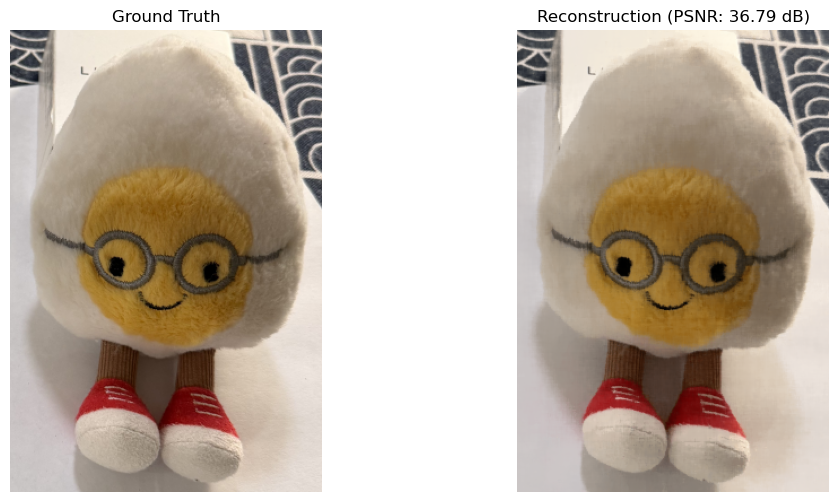

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

path = "neural2D_demo2.jpg"
L = 16
hidden_dim = 256
layers = 10
lr = 0.5e-2
batch_size = 10000
iterations = 6000
vis_every = 50
device = "cuda" if torch.cuda.is_available() else "cpu"

img_bgr = cv2.imread(path)
img_bgr = cv2.resize(img_bgr, None, fx=0.2, fy=0.2, interpolation=cv2.INTER_AREA)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
H, W = img_rgb.shape[:2]

gt_rgb = torch.from_numpy(img_rgb.reshape(-1, 3)).to(device)

xs = torch.linspace(0, 1, W)
ys = torch.linspace(0, 1, H)
grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
coords = torch.stack([grid_x, grid_y], dim=-1).reshape(-1, 2).to(device)

class PE(nn.Module):
    def __init__(self, in_dim=2, L=10):
        super(PE, self).__init__()
        self.register_buffer("freqs", 2.0 ** torch.arange(L).float() * np.pi)

    def forward(self, x):
        outs = [x]

        for f in self.freqs:
            outs.append(torch.sin(f * x))
            outs.append(torch.cos(f * x))
        return torch.cat(outs, dim=-1)
    
pe = PE(in_dim=2, L=L).to(device)
coords_pe = pe(coords)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, layers):
        super(MLP, self).__init__()
        net = []
        dim = in_dim

        for _ in range(layers):
            net += [nn.Linear(dim, hidden_dim), nn.ReLU()]
            dim = hidden_dim
        net += [nn.Linear(dim, out_dim), nn.Sigmoid()]
        self.net = nn.Sequential(*net)
    
    def forward(self, x):
        return self.net(x)
    
model = MLP(in_dim=coords_pe.shape[-1], hidden_dim=hidden_dim, out_dim=3, layers=layers).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

def psnr(pred, target):
    mse = F.mse_loss(pred, target)
    return -10.0 * torch.log10(mse + 1e-8)

N = coords_pe.shape[0]
print(f"Image: {W}x{H}, total pixels: {N}")

os.makedirs("train_snaps2", exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video = cv2.VideoWriter('training_progress2.mp4', fourcc, 8.0, (W, H))


model.train()
loss_values = []
PSNR_values = []

for it in range(iterations):
    idx = torch.randint(0, N, (batch_size,), device=device)
    pred = model(coords_pe[idx])
    loss = F.mse_loss(pred, gt_rgb[idx])
    loss_values.append(loss.item())
    PSNR_values.append(psnr(pred, gt_rgb[idx]).item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (it + 1) % 100 == 0:
        print(f"Iter {it+1}/{iterations}, MSE: {loss.item():.8f}, PSNR: {psnr(pred, gt_rgb[idx]).item():.2f} dB")

    if it <= 10 or (it + 1) % vis_every == 0 or (it == iterations - 1):
        model.eval()
        with torch.no_grad():
            pred_full = model(coords_pe).reshape(H, W, 3).clamp(0.0, 1.0).cpu().numpy()
        model.train()

        mse = float(F.mse_loss(torch.from_numpy(pred_full), torch.from_numpy(img_rgb)))
        psnr_full = 10.0 * np.log10(1.0 / (mse + 1e-8))
        
        pred_bgr = cv2.cvtColor((pred_full * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        gt_bgr = img_bgr.copy()
        bar = np.ones((H, 10, 3), dtype=np.uint8) * 255
        mosaic = cv2.hconcat([pred_bgr])
        cv2.putText(mosaic, f"PSNR: {psnr_full:.2f} dB", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2, cv2.LINE_AA)
        snap_path = f"train_snaps2/iter_{it+1:04d}_psnr_{psnr_full:.2f}dB.png"
        cv2.imwrite(snap_path, mosaic)
        # print(f"Saved snapshot to {snap_path}")
        video.write(mosaic)

np.save("training_process2.npy", {"loss": loss_values, "PSNR": PSNR_values})

video.release()

model.eval()

with torch.no_grad():
    pred_full = model(coords_pe).reshape(H, W, 3).clamp(0.0, 1.0).cpu().numpy()

mse = float(F.mse_loss(torch.from_numpy(pred_full), torch.from_numpy(img_rgb)))
psnr_full = 10.0 * np.log10(1.0 / (mse + 1e-8))
print(f"PSNR={psnr_full:.4f} dB, MSE={mse:.6f}")

pred_bgr = cv2.cvtColor((pred_full * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
gt_bgr = (img_rgb * 255.0).astype(np.uint8)[:, :, ::-1]
bar = np.ones((H, 10, 3), dtype=np.uint8) * 255
mosaic = cv2.hconcat([pred_bgr])
cv2.putText(mosaic, f"PSNR: {psnr_full:.2f} dB", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2, cv2.LINE_AA)
cv2.imwrite("recon_comparison.png", mosaic)
print("Saved comparison image to recon_comparison.png")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_rgb)
ax[0].set_title("Ground Truth")
ax[0].axis("off")
ax[1].imshow(pred_full)
ax[1].set_title(f"Reconstruction (PSNR: {psnr_full:.2f} dB)")
ax[1].axis("off")

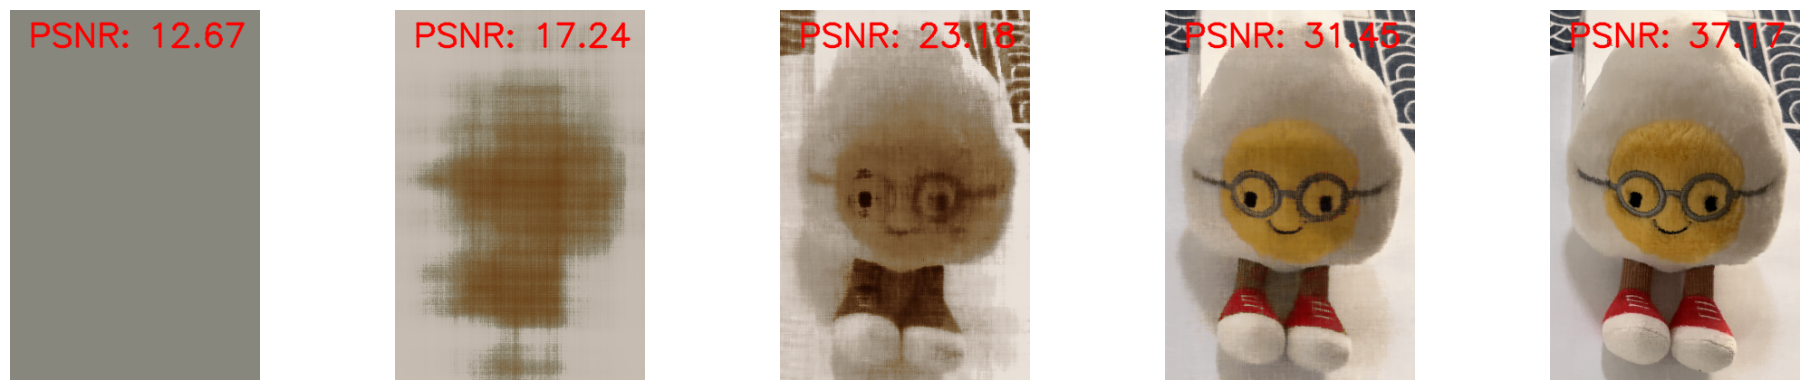

In [25]:
import matplotlib.pyplot as plt
import glob

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))
idx = 0

# for img_id in ["0001", "0050", "0100", "0400", "9600"]:
#     img_path = glob.glob(f"train_snaps/iter_{img_id}_psnr_*.png")
#     img = cv2.imread(img_path[0])
#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     ax[idx].imshow(img_rgb)
#     ax[idx].axis("off")
#     idx += 1

for img_id in ["0001", "0050", "0150", "0500", "5150"]:
    img_path = glob.glob(f"train_snaps2/iter_{img_id}_psnr_*.png")
    img = cv2.imread(img_path[0])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax[idx].imshow(img_rgb)
    ax[idx].axis("off")
    idx += 1

fig.tight_layout()
plt.show()


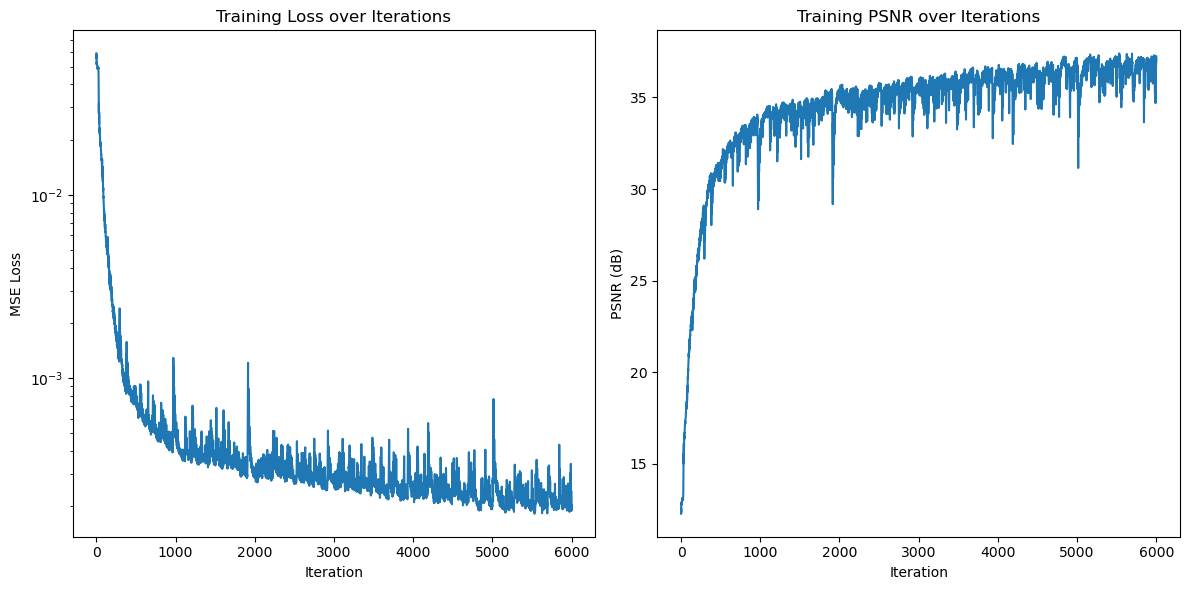

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].semilogy(loss_values)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("MSE Loss")
ax[0].set_title("Training Loss over Iterations")
ax[1].plot(PSNR_values)
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("PSNR (dB)")
ax[1].set_title("Training PSNR over Iterations")

fig.tight_layout()
plt.show()

Image: 1024x689, total pixels: 705536
Iter 100/6000, MSE: 0.00766735, PSNR: 21.15 dB
Iter 200/6000, MSE: 0.00429292, PSNR: 23.67 dB
Iter 300/6000, MSE: 0.00324747, PSNR: 24.88 dB
Iter 400/6000, MSE: 0.00291932, PSNR: 25.35 dB
Iter 500/6000, MSE: 0.00282992, PSNR: 25.48 dB
Iter 600/6000, MSE: 0.00256121, PSNR: 25.92 dB
Iter 700/6000, MSE: 0.00231636, PSNR: 26.35 dB
Iter 800/6000, MSE: 0.00249491, PSNR: 26.03 dB
Iter 900/6000, MSE: 0.00231555, PSNR: 26.35 dB
Iter 1000/6000, MSE: 0.00225390, PSNR: 26.47 dB
Iter 1100/6000, MSE: 0.00225411, PSNR: 26.47 dB
Iter 1200/6000, MSE: 0.00198271, PSNR: 27.03 dB
Iter 1300/6000, MSE: 0.00208076, PSNR: 26.82 dB
Iter 1400/6000, MSE: 0.00205930, PSNR: 26.86 dB
Iter 1500/6000, MSE: 0.00189997, PSNR: 27.21 dB
Iter 1600/6000, MSE: 0.00185611, PSNR: 27.31 dB
Iter 1700/6000, MSE: 0.00190729, PSNR: 27.20 dB
Iter 1800/6000, MSE: 0.00183673, PSNR: 27.36 dB
Iter 1900/6000, MSE: 0.00175570, PSNR: 27.56 dB
Iter 2000/6000, MSE: 0.00164709, PSNR: 27.83 dB
Iter 2100/6

(np.float64(-0.5), np.float64(1023.5), np.float64(688.5), np.float64(-0.5))

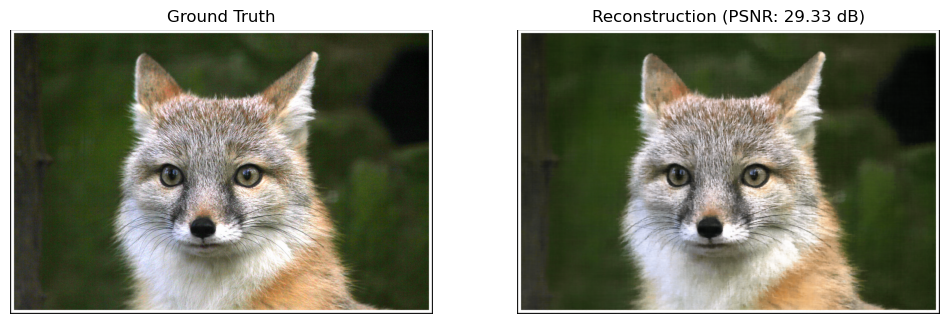

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

path = "neural2D_demo.jpg"
L = 16
hidden_dim = 256
layers = 10
lr = 0.5e-2
batch_size = 10000
iterations = 6000
vis_every = 50
device = "cuda" if torch.cuda.is_available() else "cpu"
dir_name = "train_snaps_hyperparam_L" + str(L) + "dim" + str(hidden_dim) + "layers" + str(layers)
os.makedirs(dir_name, exist_ok=True)

img_bgr = cv2.imread(path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
H, W = img_rgb.shape[:2]

gt_rgb = torch.from_numpy(img_rgb.reshape(-1, 3)).to(device)

xs = torch.linspace(0, 1, W)
ys = torch.linspace(0, 1, H)
grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
coords = torch.stack([grid_x, grid_y], dim=-1).reshape(-1, 2).to(device)

class PE(nn.Module):
    def __init__(self, in_dim=2, L=10):
        super(PE, self).__init__()
        self.register_buffer("freqs", 2.0 ** torch.arange(L).float() * np.pi)

    def forward(self, x):
        outs = [x]

        for f in self.freqs:
            outs.append(torch.sin(f * x))
            outs.append(torch.cos(f * x))
        return torch.cat(outs, dim=-1)
    
pe = PE(in_dim=2, L=L).to(device)
coords_pe = pe(coords)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, layers):
        super(MLP, self).__init__()
        net = []
        dim = in_dim

        for _ in range(layers):
            net += [nn.Linear(dim, hidden_dim), nn.ReLU()]
            dim = hidden_dim
        net += [nn.Linear(dim, out_dim), nn.Sigmoid()]
        self.net = nn.Sequential(*net)
    
    def forward(self, x):
        return self.net(x)
    
model = MLP(in_dim=coords_pe.shape[-1], hidden_dim=hidden_dim, out_dim=3, layers=layers).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

def psnr(pred, target):
    mse = F.mse_loss(pred, target)
    return -10.0 * torch.log10(mse + 1e-8)

N = coords_pe.shape[0]
print(f"Image: {W}x{H}, total pixels: {N}")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video = cv2.VideoWriter(os.path.join(dir_name, 'training_progress.mp4'), fourcc, 8.0, (W, H))


model.train()
loss_values = []
PSNR_values = []

for it in range(iterations):
    idx = torch.randint(0, N, (batch_size,), device=device)
    pred = model(coords_pe[idx])
    loss = F.mse_loss(pred, gt_rgb[idx])
    loss_values.append(loss.item())
    PSNR_values.append(psnr(pred, gt_rgb[idx]).item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (it + 1) % 100 == 0:
        print(f"Iter {it+1}/{iterations}, MSE: {loss.item():.8f}, PSNR: {psnr(pred, gt_rgb[idx]).item():.2f} dB")

    if it <= 10 or (it + 1) % vis_every == 0 or (it == iterations - 1):
        model.eval()
        with torch.no_grad():
            pred_full = model(coords_pe).reshape(H, W, 3).clamp(0.0, 1.0).cpu().numpy()
        model.train()

        mse = float(F.mse_loss(torch.from_numpy(pred_full), torch.from_numpy(img_rgb)))
        psnr_full = 10.0 * np.log10(1.0 / (mse + 1e-8))
        
        pred_bgr = cv2.cvtColor((pred_full * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        gt_bgr = img_bgr.copy()
        bar = np.ones((H, 10, 3), dtype=np.uint8) * 255
        mosaic = cv2.hconcat([pred_bgr])
        cv2.putText(mosaic, f"PSNR: {psnr_full:.2f} dB", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2, cv2.LINE_AA)
        snap_path = os.path.join(dir_name, f"iter_{it+1:04d}_psnr_{psnr_full:.2f}dB.png")
        cv2.imwrite(snap_path, mosaic)
        # print(f"Saved snapshot to {snap_path}")
        video.write(mosaic)

np.save(os.path.join(dir_name, "training_process.npy"), {"loss": loss_values, "PSNR": PSNR_values})

video.release()

model.eval()

with torch.no_grad():
    pred_full = model(coords_pe).reshape(H, W, 3).clamp(0.0, 1.0).cpu().numpy()

mse = float(F.mse_loss(torch.from_numpy(pred_full), torch.from_numpy(img_rgb)))
psnr_full = 10.0 * np.log10(1.0 / (mse + 1e-8))
print(f"PSNR={psnr_full:.4f} dB, MSE={mse:.6f}")

pred_bgr = cv2.cvtColor((pred_full * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
gt_bgr = (img_rgb * 255.0).astype(np.uint8)[:, :, ::-1]
bar = np.ones((H, 10, 3), dtype=np.uint8) * 255
mosaic = cv2.hconcat([pred_bgr])
cv2.putText(mosaic, f"PSNR: {psnr_full:.2f} dB", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2, cv2.LINE_AA)
cv2.imwrite(os.path.join(dir_name, "recon_comparison.png"), mosaic)
print("Saved comparison image to recon_comparison.png")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_rgb)
ax[0].set_title("Ground Truth")
ax[0].axis("off")
ax[1].imshow(pred_full)
ax[1].set_title(f"Reconstruction (PSNR: {psnr_full:.2f} dB)")
ax[1].axis("off")

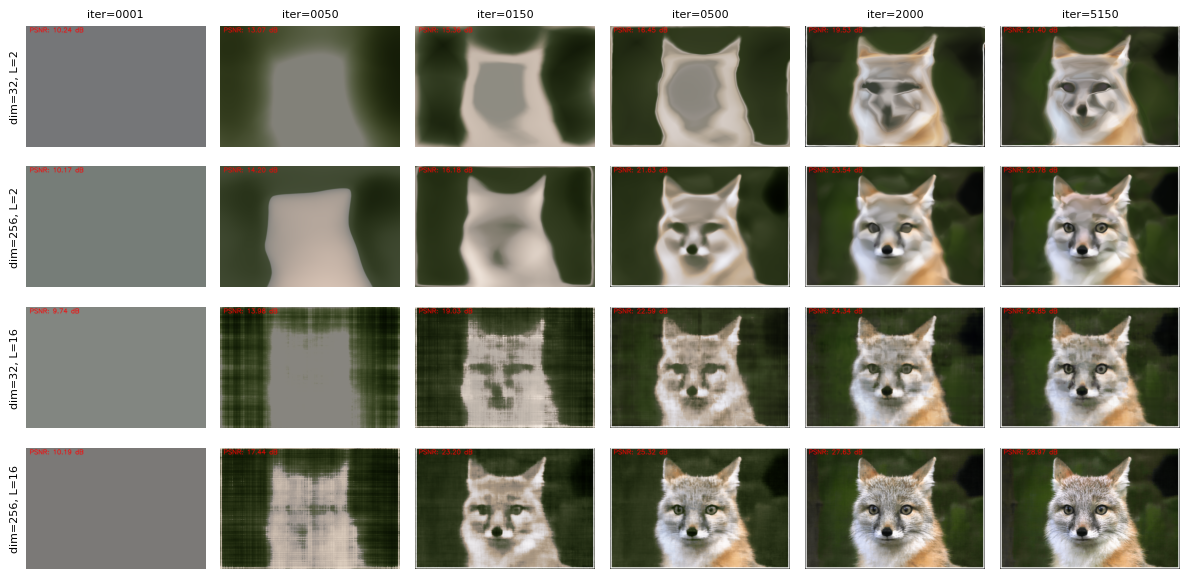

In [52]:
fig, ax = plt.subplots(nrows=4, ncols=6, figsize=(12, 6))

idx = 0
for L in [2, 16]:
    for dim in [32, 256]:
        for img_id in ["0001", "0050", "0150", "0500", "2000", "5150"]:
            dir_name = "train_snaps_hyperparam_L" + str(L) + "dim" + str(dim) + "layers10"
            img_path = glob.glob(f"{dir_name}/iter_{img_id}_psnr_*.png")
            img = cv2.imread(img_path[0])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax[idx // 6, idx % 6].imshow(img_rgb)
            if idx % 6 != 0:
                ax[idx // 6, idx % 6].axis("off")
            if idx // 6 == 0:
                ax[idx // 6, idx % 6].set_title(f"iter={img_id}", fontsize=8)

            if idx % 6 == 0:
                ax[idx // 6, 0].set_ylabel(f"dim={dim}, L={L}", fontsize=8)
                ax[idx // 6, 0].set_xticks([])
                ax[idx // 6, 0].set_yticks([])
                ax[idx // 6, 0].set_frame_on(False)

            idx += 1

fig.tight_layout()
plt.show()


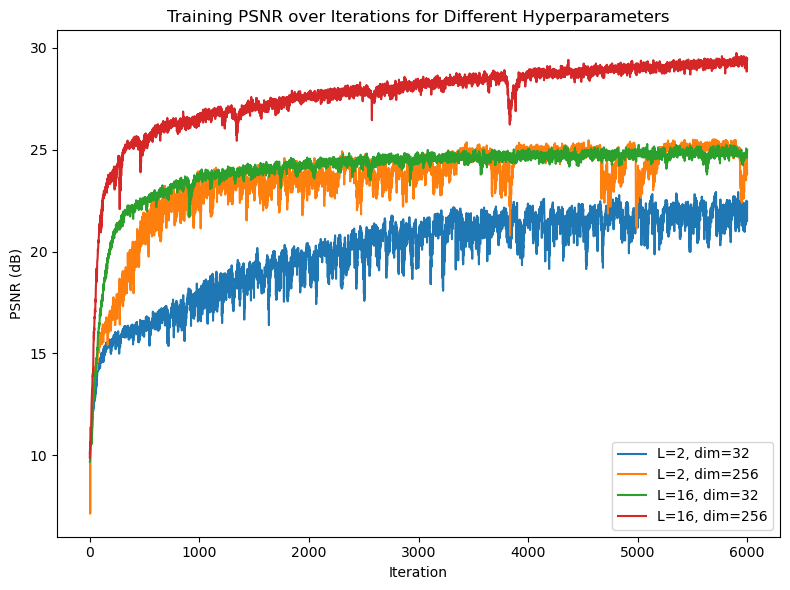

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for L in [2, 16]:
    for dim in [32, 256]:
        dir_name = "train_snaps_hyperparam_L" + str(L) + "dim" + str(dim) + "layers10"
        data = np.load(os.path.join(dir_name, "training_process.npy"), allow_pickle=True).item()
        loss_values = data["loss"]
        PSNR_values = data["PSNR"]
        ax.plot(PSNR_values, label=f"L={L}, dim={dim}")
ax.set_xlabel("Iteration")
ax.set_ylabel("PSNR (dB)")
ax.set_title("Training PSNR over Iterations for Different Hyperparameters")
ax.legend()

fig.tight_layout()
plt.show()